<a href="https://colab.research.google.com/github/positivefunctionIN/spleen_segmentation/blob/main/3d_segmentation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!python -c "import monai" || pip install -q "monai-weekly[gdown, nibabel, tqdm, ignite]"
!python -c "import matplotlib" || pip install -q matplotlib
%matplotlib inline

Traceback (most recent call last):
  File "<string>", line 1, in <module>
    import monai
ModuleNotFoundError: No module named 'monai'
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 266.5/266.5 kB 10.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 44.7 MB/s eta 0:00:00


In [ ]:
from monai.utils import first, set_determinism
from monai.transforms import (
    AsDiscrete,
    AsDiscreted,
    EnsureChannelFirstd,
    Compose,
    CropForegroundd,
    LoadImaged,
    Orientationd,
    RandCropByPosNegLabeld,
    SaveImaged,
    ScaleIntensityRanged,
    Spacingd,
    Invertd,
)
from monai.handlers.utils import from_engine
from monai.networks.nets import UNet
from monai.networks.layers import Norm
from monai.metrics import DiceMetric
from monai.losses import DiceLoss
from monai.inferers import sliding_window_inference
from monai.data import CacheDataset, DataLoader, Dataset, decollate_batch
from monai.config import print_config
from monai.apps import download_and_extract
import torch
import matplotlib.pyplot as plt
import tempfile
import shutil
import os
import glob

print_config()

MONAI version: 1.7.dev2633
Numpy version: 2.1.3
Pytorch version: 2.11.0+cu128
MONAI flags: HAS_EXT = False, USE_COMPILED = False, USE_META_DICT = False
MONAI rev id: 17ff85f5808a658c19beac995edd5c28f1ee72a3
MONAI __file__: /usr/local/lib/python3.13/dist-packages/monai/__init__.py

Optional dependencies:
Pytorch Ignite version: 0.4.11
ITK version: NOT INSTALLED or UNKNOWN VERSION.
Nibabel version: 5.4.2
scikit-image version: 0.25.2
scipy version: 1.16.3
Pillow version: 11.3.0
Tensorboard version: 2.20.0
gdown version: 5.2.2
TorchVision version: 0.26.0+cu128
tqdm version: 4.67.3
lmdb version: NOT INSTALLED or UNKNOWN VERSION.
psutil version: 5.9.5
pandas version: 2.2.3
einops version: 0.8.2
transformers version: 5.15.0
mlflow version: NOT INSTALLED or UNKNOWN VERSION.
pynrrd version: NOT INSTALLED or UNKNOWN VERSION.
clearml version: NOT INSTALLED or UNKNOWN VERSION.

For details about installing the optional dependencies, please visit:
    https://monai.readthedocs.io/en/latest/installa

In [ ]:
directory = os.environ.get("MONAI_DATA_DIRECTORY")
if directory is not None:
  os.makedirs(directory, exist_ok=True)
root_dir = tempfile.mkdtemp() if directory is None else directory
print(root_dir)

/tmp/tmpqy9lhzrr


In [ ]:

resource = "https://msd-for-monai.s3-us-west-2.amazonaws.com/Task09_Spleen.tar"
md5 = "410d4a301da4e5b2f6f86ec3ddba524e"

compressed_file = os.path.join(root_dir, "Task09_Spleen.tar")
data_dir = os.path.join(root_dir, "Task09_Spleen")
if not os.path.exists(data_dir):
    download_and_extract(resource, compressed_file, root_dir, md5)

Task09_Spleen.tar: 1.50GB [00:51, 31.2MB/s]                            


2026-08-26 06:58:21,535 - INFO - Verified 'Task09_Spleen.tar', md5: 410d4a301da4e5b2f6f86ec3ddba524e.
2026-08-26 06:58:21,536 - INFO - Downloaded: /tmp/tmpqy9lhzrr/Task09_Spleen.tar
2026-08-26 06:58:21,538 - INFO - Writing into directory: /tmp/tmpqy9lhzrr.


In [ ]:
train_images = sorted(glob.glob(os.path.join(data_dir, "imagesTr", "*.nii.gz")))
train_labels = sorted(glob.glob(os.path.join(data_dir, "labelsTr", "*.nii.gz")))
data_dicts = [{"image": image_name, "label": label_name} for image_name, label_name in zip(train_images, train_labels)]
train_files, val_files = data_dicts[:-9], data_dicts[-9:]

In [ ]:
set_determinism(seed=0)

In [ ]:
train_transforms = Compose(
    [
        LoadImaged(keys=["image", "label"]),
        EnsureChannelFirstd(keys=["image", "label"]),
        ScaleIntensityRanged(
            keys=["image"],
            a_min=-57,
            a_max=164,
            b_min=0.0,
            b_max=1.0,
            clip=True,
        ),
        CropForegroundd(keys=["image", "label"], source_key="image", allow_smaller=True),
        Orientationd(keys=["image", "label"], axcodes="RAS"),
        Spacingd(keys=["image", "label"], pixdim=(1.5, 1.5, 2.0), mode=("bilinear", "nearest")),
        RandCropByPosNegLabeld(
            keys=["image", "label"],
            label_key="label",
            spatial_size=(96, 96, 96),
            pos=1,
            neg=1,
            num_samples=4,
            image_key="image",
            image_threshold=0,
        ),

    ]
)
val_transforms = Compose(
    [
        LoadImaged(keys=["image", "label"]),
        EnsureChannelFirstd(keys=["image", "label"]),
        ScaleIntensityRanged(
            keys=["image"],
            a_min=-57,
            a_max=164,
            b_min=0.0,
            b_max=1.0,
            clip=True,
        ),
        CropForegroundd(keys=["image", "label"], source_key="image", allow_smaller=True),
        Orientationd(keys=["image", "label"], axcodes="RAS"),
        Spacingd(keys=["image", "label"], pixdim=(1.5, 1.5, 2.0), mode=("bilinear", "nearest")),
    ]
)

/usr/local/lib/python3.13/dist-packages/monai/utils/deprecate_utils.py:320: FutureWarning: monai.transforms.spatial.dictionary Orientationd.__init__:labels: Current default value of argument `labels=(('L', 'R'), ('P', 'A'), ('I', 'S'))` was changed in version None from `labels=(('L', 'R'), ('P', 'A'), ('I', 'S'))` to `labels=None`. Default value changed to None meaning that the transform now uses the 'space' of a meta-tensor, if applicable, to determine appropriate axis labels.
  warn_deprecated(argname, msg, warning_category)


image shape: torch.Size([228, 158, 113]), label shape: torch.Size([228, 158, 113])


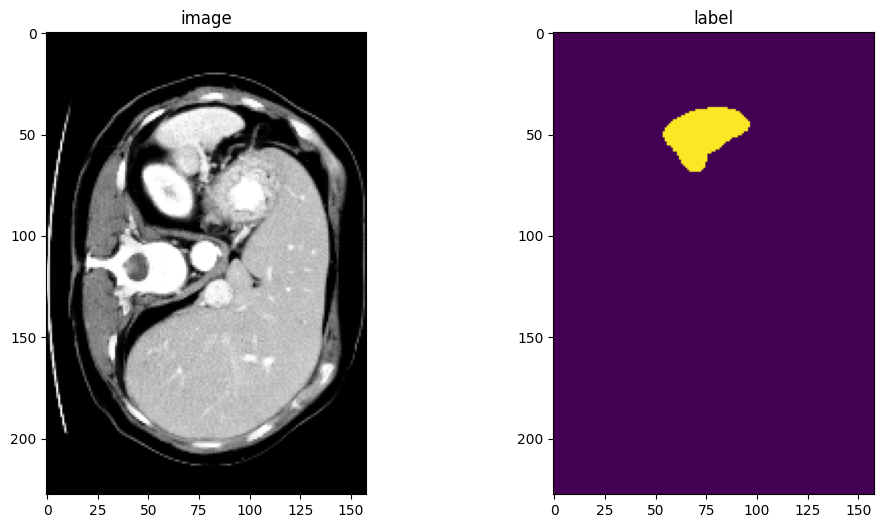

In [ ]:
check_ds = Dataset(data=val_files, transform=val_transforms)
check_loader = DataLoader(check_ds, batch_size=1)
check_data = first(check_loader)
image, label = (check_data["image"][0][0], check_data["label"][0][0])
print(f"image shape: {image.shape}, label shape: {label.shape}")
# plot the slice [:, :, 80]
plt.figure("check", (12, 6))
plt.subplot(1, 2, 1)
plt.title("image")
plt.imshow(image[:, :, 80], cmap="gray")
plt.subplot(1, 2, 2)
plt.title("label")
plt.imshow(label[:, :, 80])
plt.show()

In [ ]:
train_ds = CacheDataset(data=train_files, transform=train_transforms, cache_rate=1.0, num_workers=4)
# train_ds = Dataset(data=train_files, transform=train_transforms)

# use batch_size=2 to load images and use RandCropByPosNegLabeld
# to generate 2 x 4 images for network training
train_loader = DataLoader(train_ds, batch_size=2, shuffle=True, num_workers=4)

val_ds = CacheDataset(data=val_files, transform=val_transforms, cache_rate=1.0, num_workers=4)
# val_ds = Dataset(data=val_files, transform=val_transforms)
val_loader = DataLoader(val_ds, batch_size=1, num_workers=4)

Loading dataset: 100%|██████████| 32/32 [01:33<00:00,  2.93s/it]
/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py:424: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()
Loading dataset: 100%|██████████| 9/9 [00:20<00:00,  2.28s/it]


In [ ]:
# standard PyTorch program style: create UNet, DiceLoss and Adam optimizer
device = torch.device("cuda:0")
model = UNet(
    spatial_dims=3,
    in_channels=1,
    out_channels=2,
    channels=(16, 32, 64, 128, 256),
    strides=(2, 2, 2, 2),
    num_res_units=2,
    norm=Norm.BATCH,
).to(device)
loss_function = DiceLoss(to_onehot_y=True, softmax=True)
optimizer = torch.optim.Adam(model.parameters(), 1e-4)
dice_metric = DiceMetric(include_background=False, reduction="mean")

In [ ]:
import torch

CHECKPOINT_DIR = "/content/drive/MyDrive/monai_spleen_checkpoints"
CHECKPOINT_PATH = os.path.join(CHECKPOINT_DIR, "latest_checkpoint.pth")
BEST_MODEL_PATH = os.path.join(CHECKPOINT_DIR, "best_model.pth")
os.makedirs(CHECKPOINT_DIR, exist_ok=True)

MAX_EPOCHS = 400          # safety ceiling, not a target you must hit
VAL_INTERVAL = 2          # how often (in epochs) to run validation
PATIENCE = 20             # stop if no improvement for this many validations
SAVE_EVERY = 10           # save a resumable checkpoint every N epochs

# Variables to store training history for plotting
epoch_loss_values = []
metric_values = []

# Resume from checkpoint if one exists
start_epoch = 0
best_metric = -1
best_metric_epoch = -1
epochs_no_improve = 0

if os.path.exists(CHECKPOINT_PATH):
    print(f"Found checkpoint at {CHECKPOINT_PATH}, resuming...")
    checkpoint = torch.load(CHECKPOINT_PATH, map_location=device)
    model.load_state_dict(checkpoint["model_state_dict"])
    optimizer.load_state_dict(checkpoint["optimizer_state_dict"])
    start_epoch = checkpoint["epoch"] + 1
    best_metric = checkpoint["best_metric"]
    best_metric_epoch = checkpoint["best_metric_epoch"]
    epochs_no_improve = checkpoint.get("epochs_no_improve", 0)
    # Load historical values if they exist in the checkpoint
    epoch_loss_values = checkpoint.get("epoch_loss_values", [])
    metric_values = checkpoint.get("metric_values", [])
    print(f"Resumed at epoch {start_epoch}, best_metric so far: {best_metric:.4f}")
else:
    print("No checkpoint found, starting fresh.")

# Training loop with checkpointing + early stopping
for epoch in range(start_epoch, MAX_EPOCHS):
    print(f"\nEpoch {epoch + 1}/{MAX_EPOCHS}")
    model.train()
    epoch_loss = 0
    for batch_data in train_loader:
        inputs = batch_data["image"].to(device)
        labels = batch_data["label"].to(device)

        optimizer.zero_grad()
        outputs = model(inputs)
        loss = loss_function(outputs, labels)
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()

    epoch_loss /= len(train_loader)
    epoch_loss_values.append(epoch_loss) # Store epoch loss
    print(f"  train_loss: {epoch_loss:.4f}")

    # ---- validation ----
    if (epoch + 1) % VAL_INTERVAL == 0:
        model.eval()
        with torch.no_grad():
            for val_data in val_loader:
                val_inputs = val_data["image"].to(device)
                val_labels = val_data["label"].to(device)
                roi_size = (160, 160, 160)
                sw_batch_size = 4
                val_outputs = sliding_window_inference(
                    val_inputs, roi_size, sw_batch_size, model
                )
                val_outputs = [
                    torch.argmax(o, dim=0, keepdim=True) for o in val_outputs
                ]
                dice_metric(y_pred=val_outputs, y=val_labels)

            metric = dice_metric.aggregate().item()
            dice_metric.reset()
            metric_values.append(metric) # Store validation metric
            print(f"  val_dice: {metric:.4f}")

            if metric > best_metric:
                best_metric = metric
                best_metric_epoch = epoch + 1
                epochs_no_improve = 0
                torch.save(model.state_dict(), BEST_MODEL_PATH)
                print(f"  -> new best model saved (dice={best_metric:.4f})")
            else:
                epochs_no_improve += 1
                print(f"  no improvement for {epochs_no_improve} validation round(s)")

    # ---- save resumable checkpoint every SAVE_EVERY epochs ----
    if (epoch + 1) % SAVE_EVERY == 0:
        torch.save({
            "epoch": epoch,
            "model_state_dict": model.state_dict(),
            "optimizer_state_dict": optimizer.state_dict(),
            "best_metric": best_metric,
            "best_metric_epoch": best_metric_epoch,
            "epochs_no_improve": epochs_no_improve,
            "epoch_loss_values": epoch_loss_values, # Save historical values
            "metric_values": metric_values,         # Save historical values
        }, CHECKPOINT_PATH)
        print(f"  checkpoint saved at epoch {epoch + 1}")

    # ---- early stopping check ----
    if epochs_no_improve >= PATIENCE:
        print(f"\nEarly stopping at epoch {epoch + 1}. "
              f"Best dice {best_metric:.4f} at epoch {best_metric_epoch}.")
        break

print(f"\nTraining finished. Best val_dice: {best_metric:.4f} "
      f"at epoch {best_metric_epoch}. Best model saved to {BEST_MODEL_PATH}")

Found checkpoint at /content/drive/MyDrive/monai_spleen_checkpoints/latest_checkpoint.pth, resuming...
Resumed at epoch 280, best_metric so far: 0.9458

Epoch 281/400


/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


  train_loss: 0.2140

Epoch 282/400
  train_loss: 0.2088
  val_dice: 0.9318
  no improvement for 20 validation round(s)

Early stopping at epoch 282. Best dice 0.9458 at epoch 242.

Training finished. Best val_dice: 0.9458 at epoch 242. Best model saved to /content/drive/MyDrive/monai_spleen_checkpoints/best_model.pth


In [ ]:
print(f"train completed, best_metric: {best_metric:.4f} " f"at epoch: {best_metric_epoch}")


train completed, best_metric: 0.9458 at epoch: 242


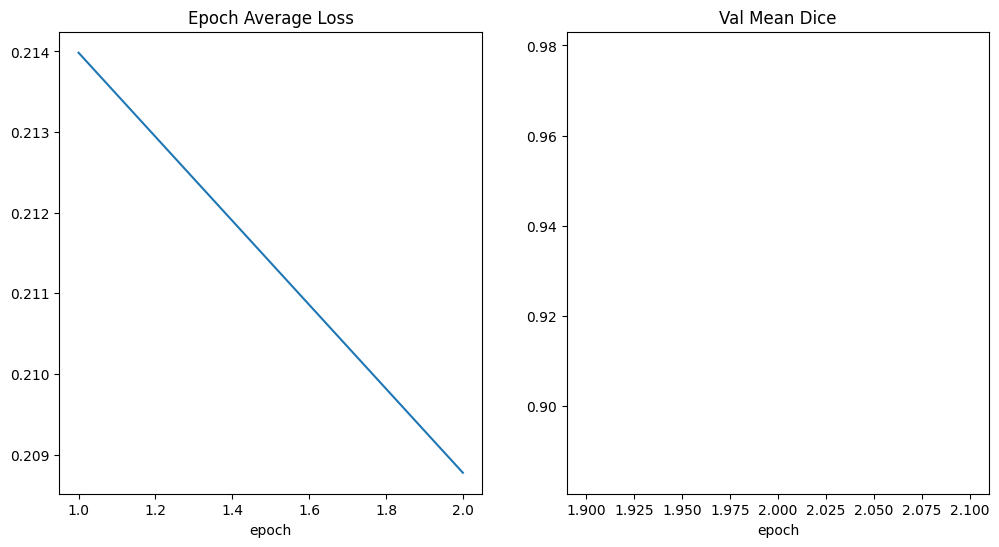

In [ ]:
plt.figure("train", (12, 6))
plt.subplot(1, 2, 1)
plt.title("Epoch Average Loss")
x = [i + 1 for i in range(len(epoch_loss_values))]
y = epoch_loss_values
plt.xlabel("epoch")
plt.plot(x, y)
plt.subplot(1, 2, 2)
plt.title("Val Mean Dice")
x = [VAL_INTERVAL * (i + 1) for i in range(len(metric_values))]
y = metric_values
plt.xlabel("epoch")
plt.plot(x, y)
plt.show()